In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

In [2]:
df = pd.read_csv("/kaggle/input/datasets/hemachander002/telecom-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
for column in df.columns:
    print(f"column name : {column}")
    print(df[column].unique())
    print()
    

column name : customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

column name : gender
['Female' 'Male']

column name : SeniorCitizen
[0 1]

column name : Partner
['Yes' 'No']

column name : Dependents
['No' 'Yes']

column name : tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

column name : PhoneService
['No' 'Yes']

column name : MultipleLines
['No phone service' 'No' 'Yes']

column name : InternetService
['DSL' 'Fiber optic' 'No']

column name : OnlineSecurity
['No' 'Yes' 'No internet service']

column name : OnlineBackup
['Yes' 'No' 'No internet service']

column name : DeviceProtection
['No' 'Yes' 'No internet service']

column name : TechSupport
['No' 'Yes' 'No internet service']

column name : StreamingTV
['No' 'Yes' 'No internet service']

column name : 

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.drop("customerID", axis=1, inplace=True)
df["Churn"] = df["Churn"].apply(lambda x : 1 if x == "Yes" else 0)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [9]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [10]:
for column in df.columns:
    print(f"column name : {column}")
    print(df[column].unique())
    print()

column name : gender
['Female' 'Male']

column name : SeniorCitizen
[0 1]

column name : Partner
['Yes' 'No']

column name : Dependents
['No' 'Yes']

column name : tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]

column name : PhoneService
['No' 'Yes']

column name : MultipleLines
['No phone service' 'No' 'Yes']

column name : InternetService
['DSL' 'Fiber optic' 'No']

column name : OnlineSecurity
['No' 'Yes' 'No internet service']

column name : OnlineBackup
['Yes' 'No' 'No internet service']

column name : DeviceProtection
['No' 'Yes' 'No internet service']

column name : TechSupport
['No' 'Yes' 'No internet service']

column name : StreamingTV
['No' 'Yes' 'No internet service']

column name : StreamingMovies
['No' 'Yes' 'No internet service']

column name : Contract
['Month-to-month' 'One year' 'Two year']

In [11]:
df["gender"] = df["gender"].apply(lambda x : 1 if x == "Male" else 0)
df["gender"].unique()

array([0, 1])

In [12]:
li = ["Partner" , "Dependents" , "PhoneService" , "PaperlessBilling"]
for col in li:
    df[col] = df[col].map({"Yes": 1, "No": 0})

for column in df.columns:
    print(f"column name : {column}")
    print(df[column].unique())
    print()

column name : gender
[0 1]

column name : SeniorCitizen
[0 1]

column name : Partner
[1 0]

column name : Dependents
[0 1]

column name : tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]

column name : PhoneService
[0 1]

column name : MultipleLines
['No phone service' 'No' 'Yes']

column name : InternetService
['DSL' 'Fiber optic' 'No']

column name : OnlineSecurity
['No' 'Yes' 'No internet service']

column name : OnlineBackup
['Yes' 'No' 'No internet service']

column name : DeviceProtection
['No' 'Yes' 'No internet service']

column name : TechSupport
['No' 'Yes' 'No internet service']

column name : StreamingTV
['No' 'Yes' 'No internet service']

column name : StreamingMovies
['No' 'Yes' 'No internet service']

column name : Contract
['Month-to-month' 'One year' 'Two year']

column name : PaperlessBilling


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   object 
 17  

In [14]:
df["avg_charge"] = df["TotalCharges"] / (df["tenure"] + 1)
df["tenure_group"] = (df["tenure"] < 12).astype(int)
df["high_value_customer"] = (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int)

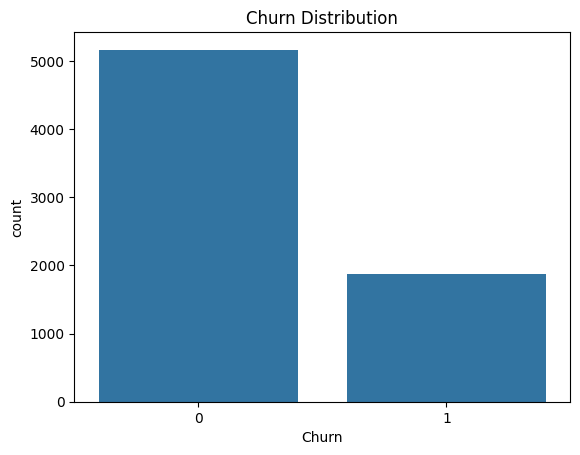

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data = df)
plt.title("Churn Distribution")
plt.show()

Text(0.5, 1.0, 'Churn Rate by Contract Type')

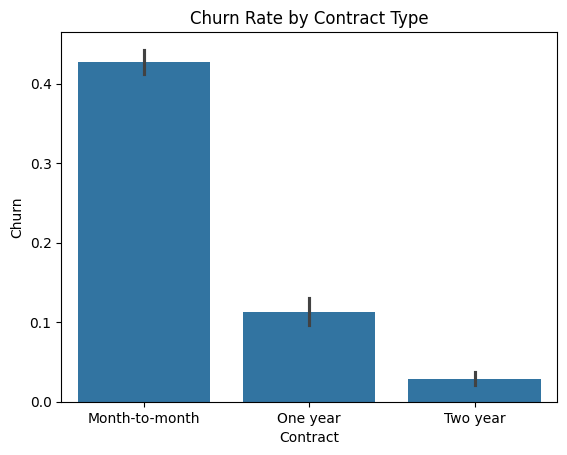

In [16]:
sns.barplot(x="Contract", y="Churn", data=df)
plt.title("Churn Rate by Contract Type")

Text(0.5, 1.0, 'Churn related to the tenure')

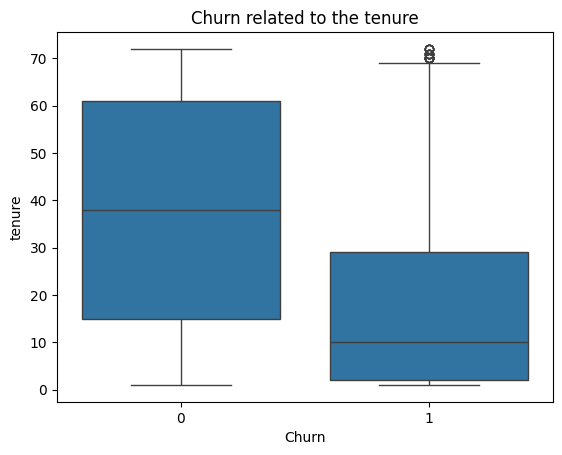

In [17]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Churn related to the tenure")

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

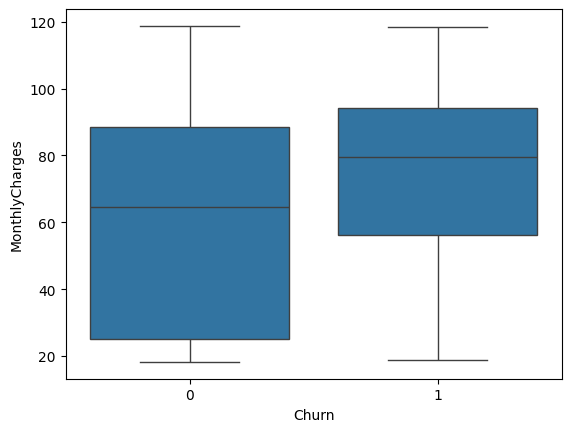

In [18]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

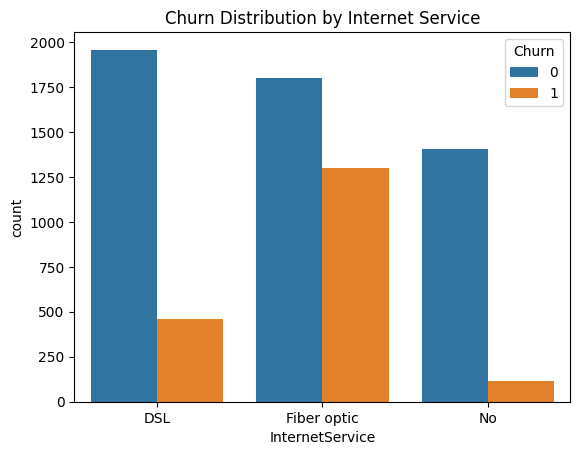

In [19]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn Distribution by Internet Service")
plt.show()

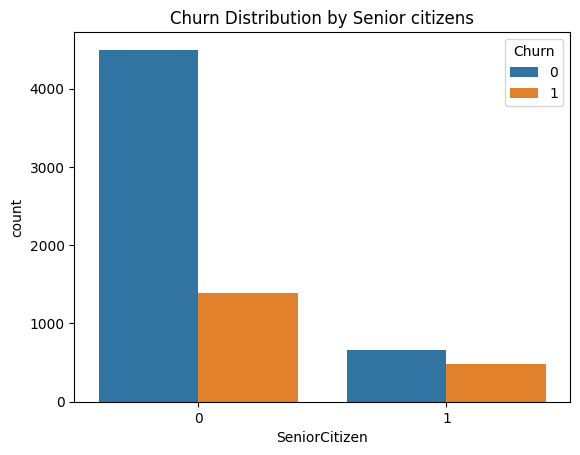

In [20]:
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Churn Distribution by Senior citizens")
plt.show()

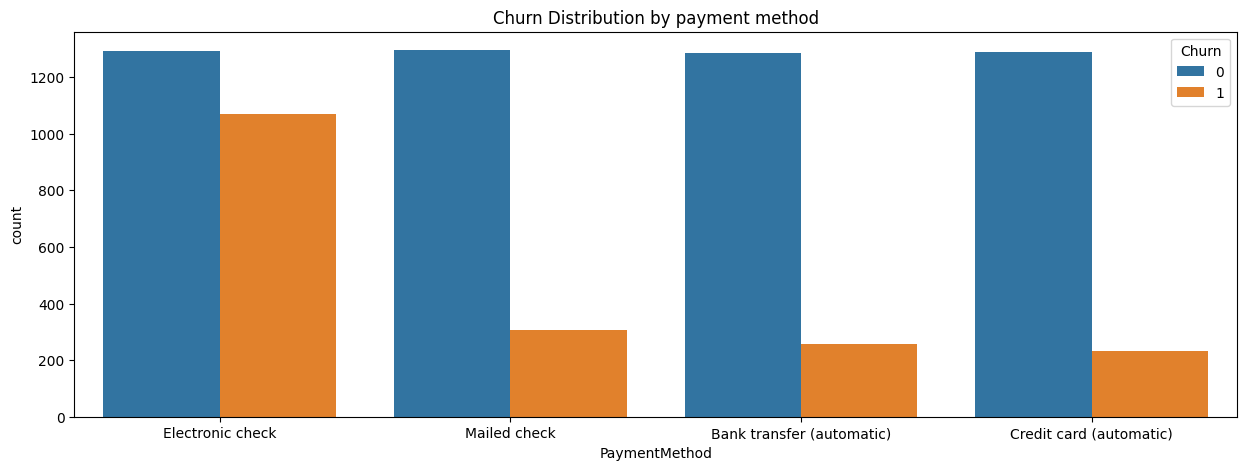

In [21]:
plt.figure(figsize = (15,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Churn Distribution by payment method")
plt.show()

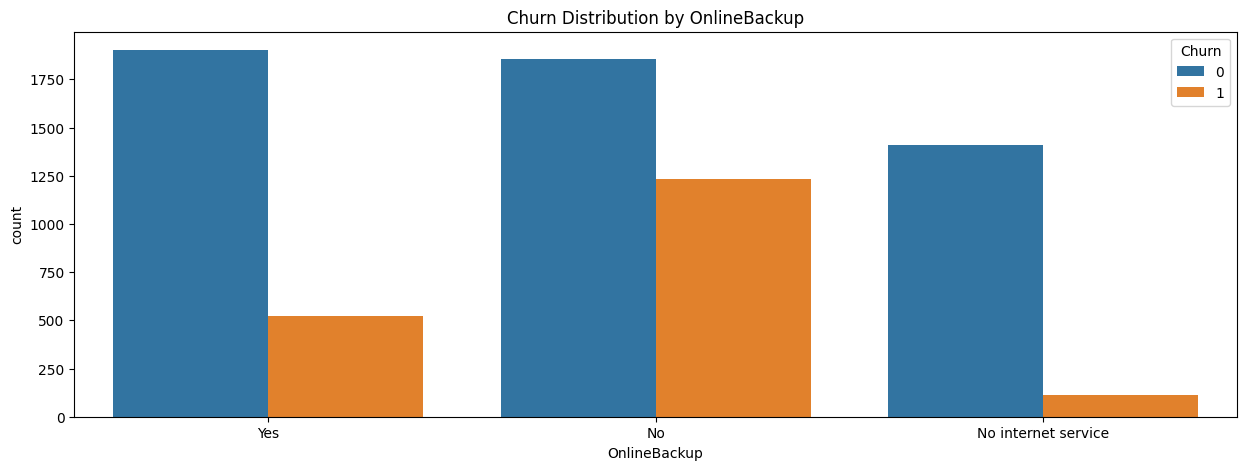

In [22]:
plt.figure(figsize = (15,5))
sns.countplot(x="OnlineBackup", hue="Churn", data=df)
plt.title("Churn Distribution by OnlineBackup")
plt.show()

In [23]:
df = pd.get_dummies(df, drop_first=True)
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   seniorcitizen                          7032 non-null   int64  
 2   partner                                7032 non-null   int64  
 3   dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   phoneservice                           7032 non-null   int64  
 6   paperlessbilling                       7032 non-null   int64  
 7   monthlycharges                         7032 non-null   float64
 8   totalcharges                           7032 non-null   float64
 9   churn                                  7032 non-null   int64  
 10  avg_charge                             7032 non-null   float64
 11  tenure_gr

In [24]:
df.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,totalcharges,churn,...,techsupport_yes,streamingtv_no_internet_service,streamingtv_yes,streamingmovies_no_internet_service,streamingmovies_yes,contract_one_year,contract_two_year,paymentmethod_credit_card_(automatic),paymentmethod_electronic_check,paymentmethod_mailed_check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [25]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [26]:
df.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,totalcharges,churn,...,techsupport_yes,streamingtv_no_internet_service,streamingtv_yes,streamingmovies_no_internet_service,streamingmovies_yes,contract_one_year,contract_two_year,paymentmethod_credit_card_(automatic),paymentmethod_electronic_check,paymentmethod_mailed_check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [27]:
x = df.drop("churn" , axis = 1)
y = df["churn"]
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42 , stratify = y)
lr = LogisticRegression(max_iter=1000 , class_weight = "balanced")
lr.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

# define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(class_weight="balanced"),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

results = {}

for name, model in models.items():
    # train
    model.fit(x_train, y_train)
    
    # predict
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]
    
    # evaluate
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# convert to dataframe
results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  F1 Score   ROC-AUC
Logistic Regression  0.729211  0.606811  0.838323
Random Forest        0.786070  0.546003  0.817581
XGBoost              0.765458  0.528571  0.812613


In [29]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier


scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)


model_params = {

    "Logistic Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(max_iter=2000))
        ]),
        "params": {
            "lr__C": [0.01, 0.1, 1, 10],
            "lr__class_weight": [None, "balanced"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": [100, 200,300],
            "max_depth": [5, 10, None,8,12],
            "min_samples_leaf": [1, 2,4],
            "class_weight": [None, "balanced"]
        }
    },

    "XGBoost": {
        "model": XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight
        ),
        "params": {
            "n_estimators": [100, 200,300],
            "max_depth": [3, 5, 7,4],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1],
            "colsample_bytree": [0.8, 1]
        }
    }
}


# -------------------------------
# 4. GridSearch Loop
# -------------------------------
results = []
best_models = {}

for name, mp in model_params.items():
    print(f"\nRunning GridSearch for {name}...")

    grid = GridSearchCV(
        mp["model"],
        mp["params"],
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    # predictions
    y_pred = best_model.predict(x_test)
    y_prob = best_model.predict_proba(x_test)[:, 1]

    # store results
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


# -------------------------------
# 5. Results Table
# -------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nFinal Results:")
print(results_df)


Running GridSearch for Logistic Regression...

Running GridSearch for Random Forest...

Running GridSearch for XGBoost...

Final Results:
                 Model                                        Best Params  \
1        Random Forest  {'class_weight': 'balanced', 'max_depth': 8, '...   
2              XGBoost  {'colsample_bytree': 1, 'learning_rate': 0.1, ...   
0  Logistic Regression      {'lr__C': 10, 'lr__class_weight': 'balanced'}   

   F1 Score   ROC-AUC  
1  0.628998  0.839828  
2  0.617587  0.838876  
0  0.609856  0.836035  


In [30]:
results_df

,Model,Best Params,F1 Score,ROC-AUC
1,Random Forest,"{'class_weight': 'balanced', 'max_depth': 8, '...",0.628998,0.839828
2,XGBoost,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.617587,0.838876
0,Logistic Regression,"{'lr__C': 10, 'lr__class_weight': 'balanced'}",0.609856,0.836035


still im not satisfied with the score so lets try random seach instead of gridsearch


In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from scipy.stats import randint, uniform


model_params = {

    "Logistic Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(max_iter=2000))
        ]),
        "params": {
            "lr__C": [0.01, 0.1, 1, 10],
            "lr__class_weight": [None, "balanced"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": randint(100, 400),
            "max_depth": [5, 8, 10, 12, None],
            "min_samples_leaf": [1, 2, 4],
            "class_weight": [{0:1, 1:2}, {0:1, 1:3}, "balanced"]
        }
    },

    "XGBoost": {
        "model": XGBClassifier(eval_metric="logloss"),
        "params": {
            "n_estimators": randint(100, 400),
            "max_depth": randint(3, 8),
            "learning_rate": uniform(0.01, 0.1),
            "subsample": uniform(0.7, 0.3),
            "colsample_bytree": uniform(0.7, 0.3),
            "scale_pos_weight": [1, 2, 3, 5]
        }
    }
}


results = []
best_models = {}

for name, mp in model_params.items():
    print(f"\nRunning RandomizedSearch for {name}...")

    search = RandomizedSearchCV(
        mp["model"],
        mp["params"],
        n_iter=30,        
        cv=3,
        scoring="f1",
        n_jobs=-1,
        random_state=42
    )

    search.fit(x_train, y_train)

    best_model = search.best_estimator_
    best_models[name] = best_model

    # predictions
    y_pred = best_model.predict(x_test)
    y_prob = best_model.predict_proba(x_test)[:, 1]

    results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nFinal Results:")
print(results_df)


Running RandomizedSearch for Logistic Regression...

Running RandomizedSearch for Random Forest...

Running RandomizedSearch for XGBoost...

Final Results:
                 Model                                        Best Params  \
1        Random Forest  {'class_weight': {0: 1, 1: 2}, 'max_depth': 8,...   
2              XGBoost  {'colsample_bytree': 0.8173181822719722, 'lear...   
0  Logistic Regression      {'lr__class_weight': 'balanced', 'lr__C': 10}   

   F1 Score   ROC-AUC  
1  0.632439  0.838576  
2  0.629291  0.840100  
0  0.609856  0.836035  


In [42]:
import numpy as np
from sklearn.metrics import f1_score

model = best_models["Random Forest"]

probs = model.predict_proba(x_test)[:, 1]

best_f1 = 0
best_threshold = 0

for t in np.arange(0.2, 0.8, 0.01):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Optimized F1:", best_f1)

Best Threshold: 0.5100000000000002
Optimized F1: 0.638755980861244


In [43]:
best_recall = 0
best_t = 0

from sklearn.metrics import recall_score

for t in np.arange(0.2, 0.8, 0.02):
    preds = (probs > t).astype(int)
    recall = recall_score(y_test, preds)
    
    if recall > best_recall:
        best_recall = recall
        best_t = t

print("Best Threshold for Recall:", best_t)
print("Recall:", best_recall)

Best Threshold for Recall: 0.2
Recall: 0.93048128342246


In [44]:

for t in [0.2, 0.3, 0.4, 0.5]:
    preds = (probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print("F1:", f1_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))


Threshold: 0.2
F1: 0.5663140764849471
Recall: 0.93048128342246

Threshold: 0.3
F1: 0.5907859078590786
Recall: 0.8743315508021391

Threshold: 0.4
F1: 0.6166328600405679
Recall: 0.8128342245989305

Threshold: 0.5
F1: 0.632438739789965
Recall: 0.7245989304812834


In [45]:
a = np.arange(0.1 , 0.9 , 0.01)

In [46]:
for t in a:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    rec = recall_score(y_test, preds)
    if (f1 >= 0.6152284263959391) & (rec >=  0.8101604278074866):
        print(f"\nThreshold: {t}")
        print("F1:", f1_score(y_test, preds))
        print("Recall:", recall_score(y_test, preds))


Threshold: 0.3799999999999999
F1: 0.6173826173826173
Recall: 0.8262032085561497

Threshold: 0.3899999999999999
F1: 0.615539858728557
Recall: 0.8155080213903744

Threshold: 0.3999999999999998
F1: 0.6166328600405679
Recall: 0.8128342245989305


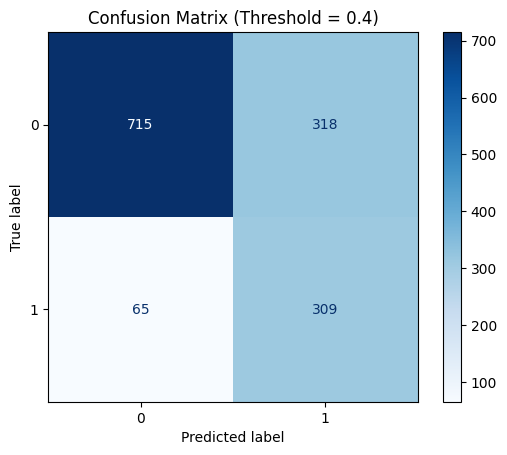

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# use your chosen threshold
threshold = 0.3799999999999999

probs = best_models["Random Forest"].predict_proba(x_test)[:, 1]
y_pred = (probs > threshold).astype(int)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Threshold = 0.4)")
plt.show()

In [53]:
import joblib

joblib.dump(model, "churn_model2.pkl")

['churn_model2.pkl']

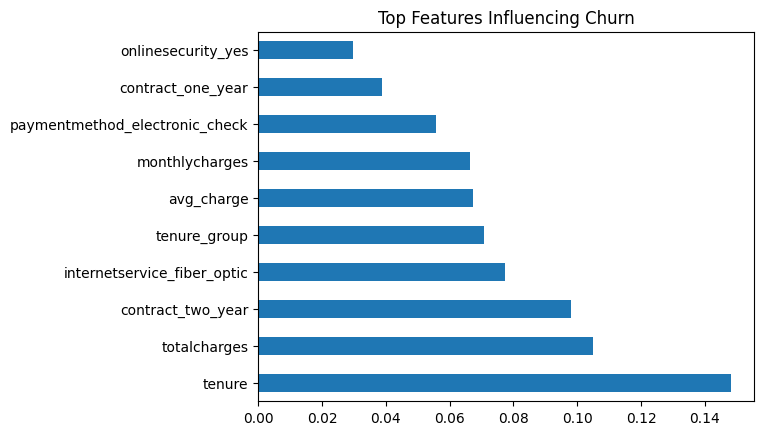

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = x.columns

feat_imp = pd.Series(importance, index=features)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top Features Influencing Churn")
plt.show()